# Бенчмаркинг квантизованной в 8bit модели

1. Модель кванитзовалась во время обучения с обучаемыми коэффициентами (LSQ)
2. Инференс дергает написанное triton-ядро в int8
3. Веса и квантизации обучались в 8битности

## Хедеры и константы

In [1]:
import zipfile
from pathlib import Path
from urllib.request import urlretrieve
import random
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap, BoundaryNorm
import torch
import segmentation_models_pytorch as smp
from tqdm.auto import tqdm
from pycocotools.coco import COCO
import numpy as np
from PIL import Image as PILImage
from torchvision.transforms import v2 as tr
# from torchvision.transforms.v2 import functional as F

import torch.nn.functional as F
from torchvision.transforms.v2 import functional as F_transform

from torch.utils.data import DataLoader, Dataset
from torchvision import tv_tensors

import colorsys
from torchvision.transforms import InterpolationMode
from torchvision.transforms.functional import pil_to_tensor

import torch_pruning as tp
import torch.nn as nn

In [2]:
ROOT_DATASET = "/home/apotapenko/private_data/Unet-Inference-Acceleration-Project/train/dataset_coco"
CKPT_PATH = "/home/apotapenko/private_data/Unet-Inference-Acceleration-Project/weights/checkpoint_coco_fp16_latest.pt"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

IGNORE_INDEX = 255

NUM_CLASSES = 81
IMAGE_SIZE = (384, 384)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

NUM_WORKERS = 8
BATCH_SIZE = 16

In [3]:
import os
import random

RANDOM_SEED = 42

def set_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # для воспроизводимости
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False

set_seed(RANDOM_SEED)

## Загрузка модели

In [4]:
model = smp.Unet(
    encoder_name="resnet101",
    encoder_weights=None,
    in_channels=3,
    classes=NUM_CLASSES,
    activation=None,
)

# baseline = model.half() # fp16
baseline = model.bfloat16() # bf16

state = torch.load(CKPT_PATH, map_location="cpu")
baseline.load_state_dict(state, strict=True)

baseline = baseline.to(DEVICE).eval()

## Формирование датасета

In [5]:
class SegTransform:
    '''
    Класс-преобразователь, который применяет аугментации к паре (image, mask)
    '''
    
    def __init__(self, size, train=True):
        self.size = size
        self.train = train
        self.mean = IMAGENET_MEAN
        self.std = IMAGENET_STD

        if train:
            self.flip = tr.RandomHorizontalFlip(p=0.5)

        self.image_prepare = tr.Compose([
            tr.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.02),
            tr.ToDtype(torch.float32, scale=True),
            tr.Normalize(mean=self.mean, std=self.std),
        ]) if train else tr.Compose([
            tr.ToDtype(torch.float32, scale=True),
            tr.Normalize(mean=self.mean, std=self.std),
        ])

    def __call__(self, image, mask):
        image = tv_tensors.Image(image)
        mask = tv_tensors.Mask(pil_to_tensor(mask).squeeze(0).to(torch.int64))

        if self.train:
            i, j, h, w = tr.RandomResizedCrop.get_params(
                image, scale=(0.6, 1.0), ratio=(3/4, 4/3)
            )
            image = F_transform.resized_crop(image, i, j, h, w, self.size,
                                   interpolation=InterpolationMode.BILINEAR, antialias=True)
            mask = F_transform.resized_crop(mask, i, j, h, w, self.size,
                                  interpolation=InterpolationMode.NEAREST)

            image, mask = self.flip(image, mask)
        else:
            image = F_transform.resize(image, self.size, interpolation=InterpolationMode.BILINEAR, antialias=True)
            mask = F_transform.resize(mask, self.size, interpolation=InterpolationMode.NEAREST)

        image = self.image_prepare(image)
        return image, mask.long()

In [7]:
class COCOSemanticDataset(Dataset):
    """
    Semantic-seg dataset на базе COCO instances.
    Возвращает:
      image: PIL.Image (RGB)
      mask:  PIL.Image (L), где:
             0 = background
             1..N = категории COCO (плотная перенумерация)
             ignore_index (по умолчанию 255) можно использовать при необходимости
    """

    def __init__(
        self,
        root=ROOT_DATASET,
        split="train2017",
        masks_root="semantic_masks",
        ann_file=None,
        transforms=None,
        ignore_index=IGNORE_INDEX,
    ):
        self.root = Path(root)
        self.split = split
        self.transforms = transforms
        self.ignore_index = ignore_index

        self.images_dir = self.root / split
        self.masks_dir = self.root / masks_root / split

        if ann_file is None:
            ann_file = self.root / "annotations" / f"instances_{split}.json"
        self.coco = COCO(str(ann_file))

        self.image_ids = sorted(self.coco.getImgIds())

        cat_ids = sorted(self.coco.getCatIds())
        cats = self.coco.loadCats(cat_ids)
        self.class_names = ["background"] + [c["name"] for c in sorted(cats, key=lambda x: x["id"])]
        self.num_classes = len(self.class_names)

        # Проверка наличия масок
        missing = 0
        for image_id in self.image_ids[:500]:  # быстрая проверка части
            info = self.coco.loadImgs(image_id)[0]
            mpath = self.masks_dir / (Path(info["file_name"]).stem + ".png")
            if not mpath.exists():
                missing += 1
        if missing > 0:
            raise FileNotFoundError(
                f"Missing precomputed masks in {self.masks_dir}. "
                f"Run build_coco_semantic_masks(...) first."
            )

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        info = self.coco.loadImgs(image_id)[0]

        image_path = self.images_dir / info["file_name"]
        mask_path = self.masks_dir / (Path(info["file_name"]).stem + ".png")

        with PILImage.open(image_path) as im:
            image = im.convert("RGB").copy()

        with PILImage.open(mask_path) as mm:
            mask = mm.convert("L").copy()

        if self.transforms is not None:
            image, mask = self.transforms(image, mask)

        return image, mask

In [8]:
val_ds = COCOSemanticDataset(
    root=ROOT_DATASET,
    split="val2017",
    masks_root="semantic_masks",
    transforms=SegTransform(size=IMAGE_SIZE, train=False),
)

loading annotations into memory...
Done (t=0.79s)
creating index...
index created!


In [9]:
def seg_collate_fn(batch):
    images, masks = zip(*batch)
    images = torch.stack(images, dim=0)
    masks = torch.stack(masks, dim=0)
    return images, masks

In [10]:
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=False,
    prefetch_factor=4,
    collate_fn=seg_collate_fn,
    timeout= 60,
)

# **torch.compile Experiment**

In [15]:
import json
import time
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader
import segmentation_models_pytorch as smp

In [16]:
DEVICE_STR = "cuda" if torch.cuda.is_available() else "cpu"

MODEL_PATH = CKPT_PATH

NUM_CLASSES_EXP = NUM_CLASSES if "NUM_CLASSES" in globals() else 81
IGNORE_INDEX_EXP = IGNORE_INDEX if "IGNORE_INDEX" in globals() else 255
INPUT_SIZE_EXP = IMAGE_SIZE if "IMAGE_SIZE" in globals() else (384, 384)

MODEL_DTYPE = torch.bfloat16 #torch.float16 torch.float32

# гиперпараметры benchmark
BENCH_BATCH_SIZES = (1, 2, 4, 8, 16, 32, 64)
METRIC_BATCH_SIZE = 1

WARMUP = 10
ITERS = 50
BENCH_BATCH_SIZE = val_loader.batch_size


COMPILE_CONFIGS = {
    "pytorch_baseline": None,
    "torch_compile_default": {
        "backend": "inductor",
        "mode": "default",
        "dynamic": False,
    },
    "torch_compile_tuned": {
        "backend": "inductor",
        "mode": "max-autotune",
        "dynamic": False,
    },
}


## model initialization

In [17]:
class LSQFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, scale, s_grad_scale, Qn, Qp):
        ctx.save_for_backward(x, scale)
        ctx.s_grad_scale = s_grad_scale
        ctx.Qn = Qn
        ctx.Qp = Qp
        
        x_scaled = x / scale
        x_clamped = torch.clamp(torch.round(x_scaled), Qn, Qp)
        x_quant = x_clamped * scale
        return x_quant

    @staticmethod
    def backward(ctx, grad_output):
        x, scale = ctx.saved_tensors
        s_grad_scale = ctx.s_grad_scale
        Qn, Qp = ctx.Qn, ctx.Qp
        
        x_scale = x / scale
        indicate_small = (x_scale <= Qn).float()
        indicate_big = (x_scale >= Qp).float()
        indicate_middle = 1.0 - indicate_small - indicate_big

        grad_scale = (indicate_small * Qn + indicate_big * Qp + 
                  indicate_middle * (-x_scale + torch.round(x_scale))) * grad_output
        grad_scale = grad_scale.sum().unsqueeze(0) * s_grad_scale
        
        grad_x = indicate_middle * grad_output
        
        return grad_x, grad_scale, None, None, None

In [19]:
class QAConv2d(nn.Conv2d):
    def __init__(self, in_channels, out_channels, kernel_size, n_bits=8, static_padding=None, **kwargs):
        super().__init__(in_channels, out_channels, kernel_size, **kwargs)
        self.n_bits = n_bits
        self.Qn = -2**(n_bits - 1)
        self.Qp = 2**(n_bits - 1) - 1
        
        self.static_padding = static_padding 
        self.weight_scale = nn.Parameter(torch.ones(1))
        self.x_scale = nn.Parameter(torch.ones(1))        
        self.initialized = False
        
        self.register_buffer('init_state', torch.tensor(False, dtype=torch.bool))
        with torch.no_grad():
            self.weight_scale.data.copy_(2 * self.weight.abs().mean() / (self.Qp**0.5))

    def forward(self, x):
        if self.static_padding is not None:
            x = self.static_padding(x)
        if self.training and not self.init_state:
            with torch.no_grad():
                self.x_scale.data.copy_(2 * max(x.abs().mean(), 1e-4) / (self.Qp**0.5))
                self.init_state.fill_(True)
        if self.training:
            weight_s_grad_scale = 1.0 / ((self.weight.numel() * self.Qp)**0.5)
            x_s_grad_scale = 1.0 / ((x.numel() * self.Qp)**0.5)
        else:
            weight_s_grad_scale =  x_s_grad_scale = 1.0

        quantized_weight = LSQFunction.apply(self.weight, self.weight_scale, weight_s_grad_scale, self.Qn, self.Qp)
        quantized_x = LSQFunction.apply(x, self.x_scale, x_s_grad_scale, self.Qn, self.Qp)

        return F.conv2d(quantized_x, quantized_weight, self.bias, self.stride, 
                        self.padding, self.dilation, self.groups)

In [20]:
class QAConv2dInference(nn.Conv2d):
    def __init__(self, original_layer):
        device = original_layer.weight.device
        super().__init__(
            original_layer.in_channels, original_layer.out_channels, original_layer.kernel_size,
            stride=original_layer.stride, padding=original_layer.padding,
            dilation=original_layer.dilation, groups=original_layer.groups,
            bias=(original_layer.bias is not None)
        )
        self.to(device)
        self.static_padding = original_layer.static_padding

        self.register_buffer('n_bits', torch.tensor(original_layer.n_bits, dtype=torch.int32, device=device))
        self.register_buffer('Qn', torch.tensor(original_layer.Qn, dtype=torch.float32, device=device))
        self.register_buffer('Qp', torch.tensor(original_layer.Qp, dtype=torch.float32, device=device))        
        self.register_buffer('x_scale', original_layer.x_scale.data.clone().to(device))

        with torch.no_grad():
            s_w = original_layer.weight_scale.clamp(min=1e-8)
            w_q = torch.clamp(torch.round(original_layer.weight / s_w), self.Qn, self.Qp) * s_w
            self.weight.copy_(w_q)
            if original_layer.bias is not None:
                self.bias.copy_(original_layer.bias)

    def forward(self, x):
        if self.static_padding is not None:
            x = self.static_padding(x)
        s_x = self.x_scale.clamp(min=1e-8)
        x = torch.clamp(torch.round(x / s_x), self.Qn, self.Qp) * s_x
        return super().forward(x)

In [18]:
import torch
import torch.nn as nn
import triton
import triton.language as tl

@triton.autotune(
    configs=[
        triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 32}, num_stages=4, num_warps=8),
        triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 64}, num_stages=4, num_warps=8),
        triton.Config({'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 256, 'BLOCK_SIZE_K': 32}, num_stages=4, num_warps=8),
        triton.Config({'BLOCK_SIZE_M': 256, 'BLOCK_SIZE_N': 64, 'BLOCK_SIZE_K': 32}, num_stages=4, num_warps=8),
        triton.Config({'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 64, 'BLOCK_SIZE_K': 32}, num_stages=5, num_warps=4),
        triton.Config({'BLOCK_SIZE_M': 32, 'BLOCK_SIZE_N': 32, 'BLOCK_SIZE_K': 32}, num_stages=5, num_warps=2),
    ],
    key=['M', 'N', 'K'],
)
@triton.jit
def lsq_conv_kernel_g1(
    x_ptr, w_ptr, bias_ptr, out_ptr,
    batch, in_c, in_h, in_w, out_c, out_h, out_w,
    kh, kw, stride_h, stride_w, padding_h, padding_w,
    scale, M, N, K,
    stride_xb, stride_xc, stride_xh, stride_xw,
    stride_w_out, stride_w_in, stride_w_kh, stride_w_kw,
    stride_out_b, stride_out_c, stride_out_h, stride_out_w,
    stride_bias,
    BLOCK_SIZE_M: tl.constexpr, BLOCK_SIZE_N: tl.constexpr, BLOCK_SIZE_K: tl.constexpr,
):
    pid = tl.program_id(0)
    num_pid_m = tl.cdiv(M, BLOCK_SIZE_M)
    pid_m = pid % num_pid_m
    pid_n = pid // num_pid_m

    offs_m = pid_m * BLOCK_SIZE_M + tl.arange(0, BLOCK_SIZE_M)
    offs_n = pid_n * BLOCK_SIZE_N + tl.arange(0, BLOCK_SIZE_N)

    batch_id = offs_m // (out_h * out_w)
    pix_id = offs_m % (out_h * out_w)
    out_y = pix_id // out_w
    out_x = pix_id % out_w

    accumulator = tl.zeros((BLOCK_SIZE_M, BLOCK_SIZE_N), dtype=tl.int32)

    for k_base in range(0, K, BLOCK_SIZE_K):
        offs_k = k_base + tl.arange(0, BLOCK_SIZE_K)
        k_ch = offs_k // (kh * kw)
        k_rem = offs_k % (kh * kw)
        k_h = k_rem // kw
        k_w = k_rem % kw

        cy = out_y[:, None] * stride_h + k_h[None, :] - padding_h
        cx = out_x[:, None] * stride_w + k_w[None, :] - padding_w
        
        mask_x = (offs_m[:, None] < M) & (offs_k[None, :] < K) & \
                 (cy >= 0) & (cy < in_h) & (cx >= 0) & (cx < in_w)

        off_x = (batch_id[:, None].to(tl.int64) * stride_xb + k_ch[None, :].to(tl.int64) * stride_xc + 
                 cy.to(tl.int64) * stride_xh + cx.to(tl.int64) * stride_xw)
        off_w = (offs_n[None, :].to(tl.int64) * stride_w_out + k_ch[:, None].to(tl.int64) * stride_w_in + 
                 k_h[:, None].to(tl.int64) * stride_w_kh + k_w[:, None].to(tl.int64) * stride_w_kw)
        
        a = tl.load(x_ptr + off_x, mask=mask_x, other=0).to(tl.int8)
        b = tl.load(w_ptr + off_w, mask=(offs_k[:, None] < K) & (offs_n[None, :] < N), other=0).to(tl.int8)
        accumulator += tl.dot(a, b)

    bias_vals = tl.load(bias_ptr + offs_n * stride_bias, mask=offs_n < N, other=0.0)
    ##################################ZAMENA################################################
    out = accumulator.to(tl.bfloat16) * scale + bias_vals[None, :].to(tl.bfloat16)
    ##################################ZAMENA################################################

    off_out = (batch_id[:, None].to(tl.int64) * stride_out_b + offs_n[None, :].to(tl.int64) * stride_out_c + 
               out_y[:, None].to(tl.int64) * stride_out_h + out_x[:, None].to(tl.int64) * stride_out_w)
    tl.store(out_ptr + off_out, out, mask=(offs_m[:, None] < M) & (offs_n[None, :] < N))

In [21]:
class LSQConv2dTriton(nn.Module):
    def __init__(self, lsq_layer):
        super().__init__()
        self.stride = lsq_layer.stride
        self.padding = lsq_layer.padding
        self.static_padding = getattr(lsq_layer, 'static_padding', None)
        
        device = lsq_layer.weight.device

        self.register_buffer('Qn', torch.tensor(lsq_layer.Qn, dtype=torch.float32, device=device))
        self.register_buffer('Qp', torch.tensor(lsq_layer.Qp, dtype=torch.float32, device=device))
        self.register_buffer('x_scale', lsq_layer.x_scale.data.clone().to(device))
        
        with torch.no_grad():
            sw = lsq_layer.weight_scale.data
            sa = lsq_layer.x_scale.data
            self.combined_scale = (sw * sa).item()

            w_int = torch.clamp(torch.round(lsq_layer.weight.data / sw), lsq_layer.Qn, lsq_layer.Qp).to(torch.int8)
            self.register_buffer('weight_int', w_int.to(memory_format=torch.channels_last))

            if lsq_layer.bias is not None:
                self.register_buffer('bias', lsq_layer.bias.data.clone())
            else:
                self.register_buffer('bias', torch.zeros(lsq_layer.out_channels, device=sw.device))
                
        self.out_c, self.in_c, self.kh, self.kw = self.weight_int.shape
        self.K_val = self.in_c * self.kh * self.kw
        self.sh, self.sw = (self.stride, self.stride) if isinstance(self.stride, int) else self.stride
        self.ph, self.pw = (self.padding, self.padding) if isinstance(self.padding, int) else self.padding

    def forward(self, x):
        if not x.is_contiguous(memory_format=torch.channels_last):
            x = x.to(memory_format=torch.channels_last)

        if self.static_padding is not None:
            x = self.static_padding(x)

        x_q = torch.clamp(torch.round(x / self.x_scale), self.Qn, self.Qp).to(torch.int8)
        
        B, C, H, W = x_q.shape
        OH, OW = (H + 2*self.ph - self.kh) // self.sh + 1, (W + 2*self.pw - self.kw) // self.sw + 1
        M, N = B * OH * OW, self.out_c
        
        ##################################ZAMENA################################################
        output = torch.empty((B, self.out_c, OH, OW), device=x.device, 
                             dtype=torch.bfloat16, memory_format=torch.channels_last)
        ##################################ZAMENA################################################
        
        grid = lambda META: (triton.cdiv(M, META['BLOCK_SIZE_M']) * triton.cdiv(self.out_c, META['BLOCK_SIZE_N']),)

        lsq_conv_kernel_g1[grid](
            x_q, self.weight_int, self.bias, output,
            B, C, H, W, self.out_c, OH, OW, self.kh, self.kw, self.sh, self.sw, self.ph, self.pw,
            self.combined_scale, M, self.out_c, self.K_val,
            x_q.stride(0), x_q.stride(1), x_q.stride(2), x_q.stride(3),
            self.weight_int.stride(0), self.weight_int.stride(1), self.weight_int.stride(2), self.weight_int.stride(3),
            output.stride(0), output.stride(1), output.stride(2), output.stride(3),
            self.bias.stride(0)
        )
        return output

def convert_qaconv_to_triton(model):
    """
    Заменяет все QAConv2d с groups=1 на Triton-версию.
    Групповые свертки (Depthwise) заменяются на QAConv2dInference.
    """
    def replace_recursive(module):
        for name, child in module.named_children():
            if isinstance(child, QAConv2d):
                if child.groups == 1:
                    setattr(module, name, LSQConv2dTriton(child))
                else:
                    setattr(module, name, QAConv2dInference(child))
            else:
                replace_recursive(child)
    
    replace_recursive(model)
    return model

In [22]:
def replace_conv_in_specific_parts(model, parts_to_replace=['encoder', 'decoder'], bit_width=8):
    """
    Заменяет свёртки на QAConv2d в указанных частях модели
    
    Args:
        model: модель
        parts_to_replace: ['encoder', 'decoder', 'segmentation_head']
        bit_width: количество бит для квантования
    """
    def  replace_conv_with_lsq(module, n_bits):
        if isinstance(module, QAConv2d):
            return

        for name, child in module.named_children():
            # вручную пропускаем свёртки, которые не хотим менять
            if name in ('_conv_stem', '_conv_head'):
                print(f'Пропускаем {name}')
                continue
            if isinstance(child, nn.Conv2d):
                static_padding = None
                if hasattr(child, 'static_padding') and child.static_padding is not None:
                    if not isinstance(child.static_padding, nn.Identity):
                        static_padding = child.static_padding

                bias = child.bias is not None

                lsq_conv = QAConv2d(
                    child.in_channels,
                    child.out_channels,
                    child.kernel_size,
                    n_bits=n_bits,
                    static_padding=static_padding,
                    stride=child.stride,
                    padding=child.padding,
                    dilation=child.dilation,
                    groups=child.groups,
                    bias=bias,
                )

                lsq_conv.weight.data.copy_(child.weight.data)
                if bias:
                    lsq_conv.bias.data.copy_(child.bias.data)

                setattr(module, name, lsq_conv)
            else:
                replace_conv_with_lsq(child, n_bits)
    

    if isinstance(parts_to_replace, str):
        parts_to_replace = [parts_to_replace]

    for part_name in parts_to_replace:
        if hasattr(model, part_name):
            part_module = getattr(model, part_name)
            replace_conv_with_lsq(part_module, bit_width)

In [23]:
def get_model_param_dtype(model):
    return next(model.parameters()).dtype


def cast_tensor_to_model_dtype(x, model):
    dtype = get_model_param_dtype(model)
    if dtype in (torch.float16, torch.bfloat16, torch.float32):
        return x.to(dtype=dtype)
    return x


def build_model_and_load_ckpt(path=MODEL_PATH, dtype=MODEL_DTYPE, device=DEVICE_STR):
    model = smp.Unet(
        encoder_name="resnet101",
        encoder_weights=None,
        in_channels=3,
        classes=NUM_CLASSES_EXP,
        activation=None,
    )
    replace_conv_in_specific_parts(model, parts_to_replace=['encoder', 'decoder'], bit_width=8)
    
    state = torch.load("/home/apotapenko/private_data/Unet-Inference-Acceleration-Project/weights/checkpoint_coco_quantization.pt", map_location="cpu")
    model.load_state_dict(state, strict=True)


    print("Loaded model dtype:", next(model.parameters()).dtype)
    model = convert_qaconv_to_triton(model)
    model.to(memory_format=torch.channels_last)

    model = model.to(dtype=dtype).to(device).eval()
    print("Loaded model dtype:", next(model.parameters()).dtype)
    return model


## Loader для torch.compile

In [24]:
def make_loader_like(base_loader, batch_size, shuffle=False, drop_last=False):
    num_workers = getattr(base_loader, "num_workers", 0)

    kwargs = dict(
        dataset=base_loader.dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=getattr(base_loader, "pin_memory", False),
        collate_fn=base_loader.collate_fn,
        drop_last=drop_last,
    )

    if num_workers > 0 and hasattr(base_loader, "persistent_workers"):
        kwargs["persistent_workers"] = getattr(base_loader, "persistent_workers", False)

    if num_workers > 0 and hasattr(base_loader, "prefetch_factor"):
        prefetch_factor = getattr(base_loader, "prefetch_factor", None)
        if prefetch_factor is not None:
            kwargs["prefetch_factor"] = prefetch_factor

    if hasattr(base_loader, "timeout"):
        kwargs["timeout"] = getattr(base_loader, "timeout", 0)

    return DataLoader(**kwargs)

In [25]:
def make_compile_eval_loader(base_loader):
    kwargs = dict(
        dataset=base_loader.dataset,
        batch_size=base_loader.batch_size,
        shuffle=False,
        num_workers=base_loader.num_workers,
        pin_memory=getattr(base_loader, "pin_memory", False),
        collate_fn=base_loader.collate_fn,
        drop_last=True,
    )

    if hasattr(base_loader, "persistent_workers"):
        kwargs["persistent_workers"] = getattr(base_loader, "persistent_workers", False)

    if hasattr(base_loader, "prefetch_factor"):
        try:
            kwargs["prefetch_factor"] = getattr(base_loader, "prefetch_factor")
        except Exception:
            pass

    if hasattr(base_loader, "timeout"):
        kwargs["timeout"] = getattr(base_loader, "timeout", 0)

    return DataLoader(**kwargs)


## bencmark функции

In [26]:
def get_first_batch_from_loader(loader, device):
    images, _ = next(iter(loader))
    return images.to(device, non_blocking=True)

In [27]:
def get_benchmark_input(loader, batch_size=1, device="cpu"):
    images, _ = next(iter(loader))
    x = images[:batch_size].contiguous()
    return x.to(device)


@torch.no_grad()
def warmup_model(model, x, device, warmup=WARMUP):
    model.eval()
    x_run = cast_tensor_to_model_dtype(x.to(device), model)

    for _ in range(warmup):
        _ = model(x_run)

    if device.startswith("cuda"):
        torch.cuda.synchronize()


@torch.no_grad()
def measure_first_run_compile_overhead(model, x, device):
    model.eval()
    x_run = cast_tensor_to_model_dtype(x.to(device), model)

    if device.startswith("cuda"):
        torch.cuda.synchronize()

    t0 = time.perf_counter()
    _ = model(x_run)
    if device.startswith("cuda"):
        torch.cuda.synchronize()
    t1 = time.perf_counter()

    return float(t1 - t0)


@torch.no_grad()
def benchmark_torch_model(model, x, device, warmup=WARMUP, iters=ITERS):
    model.eval()
    x_run = cast_tensor_to_model_dtype(x.to(device), model)

    # warmup
    for _ in range(warmup):
        _ = model(x_run)
    if device.startswith("cuda"):
        torch.cuda.synchronize()

    times = []
    for _ in range(iters):
        t0 = time.perf_counter()
        _ = model(x_run)
        if device.startswith("cuda"):
            torch.cuda.synchronize()
        t1 = time.perf_counter()
        times.append((t1 - t0) * 1000.0)

    times = np.array(times, dtype=np.float64)
    mean_ms = float(times.mean())

    return {
        "latency_ms": mean_ms,
        "throughput_img_s": float(x_run.shape[0] / (mean_ms / 1000.0)),
    }


def benchmark_single_batch_size(model, base_loader, batch_size, device):
    bench_loader = make_loader_like(
        base_loader,
        batch_size=batch_size,
        shuffle=False,
        drop_last=True,
    )

    x_bench = get_first_batch_from_loader(bench_loader, device)
    bench = benchmark_torch_model(
        model,
        x_bench,
        device,
        warmup=WARMUP,
        iters=ITERS,
    )

    return {
        "latency_ms": float(bench["latency_ms"]),
        "throughput_img_s": float(bench["throughput_img_s"]),
    }


def benchmark_all_batch_sizes(model, base_loader, batch_sizes, device):
    batch_results = {}

    for bs in batch_sizes:
        try:
            res = benchmark_single_batch_size(model, base_loader, bs, device)
            batch_results[int(bs)] = res

        except RuntimeError as e:
            err_text = str(e)

            if "out of memory" in err_text.lower():
                print(f"[WARN] OOM for batch_size={bs}: {err_text}")
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()

                batch_results[int(bs)] = {
                    "latency_ms": np.nan,
                    "throughput_img_s": np.nan,
                    "error": err_text,
                }
            else:
                raise

    return batch_results


@torch.no_grad()
def per_class_iou_compile(
    model,
    loader,
    device,
    num_classes=NUM_CLASSES_EXP,
    ignore_index=IGNORE_INDEX_EXP,
):
    model.eval()
    confmat = torch.zeros((num_classes, num_classes), dtype=torch.int64, device=device)

    for images, masks in loader:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True).long()

        images = cast_tensor_to_model_dtype(images, model)

        logits = model(images)
        preds = logits.argmax(dim=1)

        valid = masks != ignore_index
        t = masks[valid]
        p = preds[valid]
        if t.numel() == 0:
            continue

        idx = t * num_classes + p
        confmat += torch.bincount(idx, minlength=num_classes**2).reshape(num_classes, num_classes)

    tp = confmat.diag()
    fp = confmat.sum(0) - tp
    fn = confmat.sum(1) - tp
    denom = tp + fp + fn

    iou = tp.float() / torch.clamp(denom.float(), min=1.0)
    present = denom > 0
    miou_present = iou[present].mean().item()

    class_names = None
    if hasattr(loader.dataset, "class_names"):
        class_names = loader.dataset.class_names
    else:
        class_names = [str(i) for i in range(num_classes)]

    rows = []
    for i in range(num_classes):
        rows.append({
            "class_id": i,
            "class_name": class_names[i],
            "iou": float(iou[i].item()),
            "present_in_val": bool(present[i].item()),
            "pixels_gt_or_pred": int(denom[i].item()),
        })

    return rows, miou_present


def evaluate_main_metric(model, base_loader, device, metric_batch_size=1):
    metric_loader = make_loader_like(
        base_loader,
        batch_size=metric_batch_size,
        shuffle=False,
        drop_last=False,
    )

    rows, metric_value = per_class_iou_compile(
        model,
        metric_loader,
        device,
        num_classes=NUM_CLASSES_EXP,
        ignore_index=IGNORE_INDEX_EXP,
    )

    return rows, float(metric_value)

## Главная функция эксперимента

In [28]:
def build_inference_method(method_name, base_model):
    model = deepcopy(base_model).eval()

    if method_name == "pytorch_baseline":
        return model

    cfg = COMPILE_CONFIGS[method_name]
    compiled_model = torch.compile(
        model,
        backend=cfg["backend"],
        mode=cfg["mode"],
        dynamic=cfg["dynamic"],
    )
    return compiled_model

In [29]:
def run_torch_compile_experiment(
    val_loader,
    model_loaded=None,
    checkpoint_path=MODEL_PATH,
    model_dtype=MODEL_DTYPE,
    benchmark_batch_sizes=BENCH_BATCH_SIZES,
    metric_batch_size=METRIC_BATCH_SIZE,
):
    if model_loaded is None:
        model_loaded = build_model_and_load_ckpt(
            path=checkpoint_path,
            dtype=model_dtype,
            device=DEVICE_STR,
        )

    base_model = deepcopy(model_loaded).to(DEVICE_STR).eval()
    native_dtype = get_model_param_dtype(base_model)

    print("Native model dtype:", native_dtype)
    print("Benchmark batch sizes:", benchmark_batch_sizes)
    print("Metric batch size:", metric_batch_size)

    results = {}
    per_class_rows = {}

    for method_name in COMPILE_CONFIGS.keys():
        print(f"\n=== Running method: {method_name} ===")

        if method_name != "pytorch_baseline" and hasattr(torch, "_dynamo"):
            try:
                torch._dynamo.reset()
            except Exception:
                pass

        model_method = build_inference_method(method_name, base_model)

        # 1. benchmark по batch_size
        batch_results = benchmark_all_batch_sizes(
            model=model_method,
            base_loader=val_loader,
            batch_sizes=benchmark_batch_sizes,
            device=DEVICE_STR,
        )

        # 2. главная метрика — один раз на фиксированном batch size
        rows, metric_value = evaluate_main_metric(
            model=model_method,
            base_loader=val_loader,
            device=DEVICE_STR,
            metric_batch_size=metric_batch_size,
        )

        results[method_name] = {
            "dtype": str(native_dtype).replace("torch.", ""),
            "main_metric_name": "mIoU",
            "main_metric": float(metric_value),
            "batch_results": batch_results,
        }

        per_class_rows[method_name] = rows

        del model_method
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    print("\n=== RAW RESULTS ===")
    print(json.dumps(results, indent=2, ensure_ascii=False))

    return {
        "results": results,
        "per_class_rows": per_class_rows,
    }

## Функции отображения результатов

In [30]:
def show_torch_compile_report(
    exp_out,
    title="bf16 models",
    baseline_method="pytorch_baseline",
    batch_sizes=(1, 2, 4, 8, 16, 32, 64),
):
    if isinstance(exp_out, dict) and "results" in exp_out:
        results = exp_out["results"]
    else:
        results = exp_out

    def _extract_main_metric(vals):
        if "main_metric" in vals:
            return vals.get("main_metric_name", "Main metric"), float(vals["main_metric"])
        if "miou_present" in vals:
            return "mIoU", float(vals["miou_present"])
        return "Main metric", np.nan

    def _infer_batch_size_from_old_format(vals):
        if "benchmark_batch_size" in vals:
            try:
                return int(vals["benchmark_batch_size"])
            except Exception:
                pass

        if "latency_ms" in vals and "throughput_img_s" in vals:
            try:
                bs = vals["throughput_img_s"] * vals["latency_ms"] / 1000.0
                bs = int(round(bs))
                if bs > 0:
                    return bs
            except Exception:
                pass

        return None

    rows_latency = []
    rows_throughput = []
    rows_metric = []
    errors = []

    method_order = [
        "pytorch_baseline",
        "torch_compile_default",
        "torch_compile_tuned",
        "tvm_relax_tir"
    ]

    pretty_names_ru = {
        "pytorch_baseline": "Оригинальная\n",
        "torch_compile_default": "torch.compile\n(default)",
        "torch_compile_tuned": "torch.compile\n(tuned)",
        "tvm_relax_tir": "TVM Relax"
    }

    pretty_names_table = {
        "pytorch_baseline": "Оригинальная модель",
        "torch_compile_default": "Компиляция torch (torch.compile default)",
        "torch_compile_tuned": "Компиляция torch с подобранными параметрами (torch.compile tuned)",
        "tvm_relax_tir": "TVM Relax"
    }

    for method, vals in results.items():
        if not isinstance(vals, dict):
            errors.append({"method": method, "error": f"Unexpected value type: {type(vals)}"})
            continue

        if "error" in vals:
            errors.append({"method": method, "error": vals["error"]})
            continue

        dtype = vals.get("dtype", "")
        metric_name, metric_value = _extract_main_metric(vals)


        if "batch_results" in vals or "batch_benchmarks" in vals:
            if "batch_results" in vals:
                batch_results = vals["batch_results"]
            else:
                batch_results = vals["batch_benchmarks"]
            batch_results_norm = {}
            for k, v in batch_results.items():
                try:
                    batch_results_norm[int(k)] = v
                except Exception:
                    pass

            if 1 in batch_results_norm and "latency_ms" in batch_results_norm[1]:
                latency_1img_ms = float(batch_results_norm[1]["latency_ms"])
            else:
                available_bs = sorted(batch_results_norm.keys())
                if len(available_bs) == 0:
                    errors.append({"method": method, "error": "batch_results пустой"})
                    continue
                bs0 = available_bs[0]
                if "latency_ms" not in batch_results_norm[bs0]:
                    errors.append({"method": method, "error": f"Для batch={bs0} нет latency_ms"})
                    continue
                latency_1img_ms = float(batch_results_norm[bs0]["latency_ms"]) / bs0

            rows_latency.append({
                "method": method,
                "pretty_method": pretty_names_ru.get(method, method),
                "pretty_method_table": pretty_names_table.get(method, method),
                "dtype": dtype,
                "latency_1img_ms": latency_1img_ms,
            })

            thr_row = {
                "method": method,
                "pretty_method": pretty_names_ru.get(method, method),
                "pretty_method_table": pretty_names_table.get(method, method),
                "dtype": dtype,
            }
            for bs in batch_sizes:
                if bs in batch_results_norm and "throughput_img_s" in batch_results_norm[bs]:
                    thr_row[f"throughput_bs{bs}"] = float(batch_results_norm[bs]["throughput_img_s"])
                else:
                    thr_row[f"throughput_bs{bs}"] = np.nan
            rows_throughput.append(thr_row)


        else:
            required_keys = ["latency_ms", "throughput_img_s"]
            missing = [k for k in required_keys if k not in vals]
            if missing:
                errors.append({"method": method, "error": f"Missing keys: {missing}"})
                continue

            inferred_bs = _infer_batch_size_from_old_format(vals)
            if inferred_bs is None:
                errors.append({
                    "method": method,
                    "error": "Не удалось восстановить benchmark_batch_size из latency_ms и throughput_img_s"
                })
                continue

            latency_1img_ms = float(vals["latency_ms"]) / inferred_bs

            rows_latency.append({
                "method": method,
                "pretty_method": pretty_names_ru.get(method, method),
                "pretty_method_table": pretty_names_table.get(method, method),
                "dtype": dtype,
                "latency_1img_ms": latency_1img_ms,
            })

            thr_row = {
                "method": method,
                "pretty_method": pretty_names_ru.get(method, method),
                "pretty_method_table": pretty_names_table.get(method, method),
                "dtype": dtype,
            }
            for bs in batch_sizes:
                thr_row[f"throughput_bs{bs}"] = np.nan


            if inferred_bs in batch_sizes:
                thr_row[f"throughput_bs{inferred_bs}"] = float(vals["throughput_img_s"])

            rows_throughput.append(thr_row)

        rows_metric.append({
            "method": method,
            "pretty_method": pretty_names_ru.get(method, method),
            "pretty_method_table": pretty_names_table.get(method, method),
            "dtype": dtype,
            "metric_name": metric_name,
            "main_metric": metric_value,
            "main_metric_percent": metric_value * 100.0 if pd.notna(metric_value) else np.nan,
        })

    latency_df = pd.DataFrame(rows_latency)
    throughput_df = pd.DataFrame(rows_throughput)
    metric_df = pd.DataFrame(rows_metric)
    err_df = pd.DataFrame(errors)

    if latency_df.empty and throughput_df.empty and metric_df.empty:
        print("Нет валидных результатов.")
        if not err_df.empty:
            display(err_df)
        return {
            "latency_df": latency_df,
            "throughput_df": throughput_df,
            "metric_df": metric_df,
            "errors_df": err_df,
        }

    def _sort_df(df):
        if df.empty:
            return df
        df["method"] = pd.Categorical(df["method"], categories=method_order, ordered=True)
        return df.sort_values("method").reset_index(drop=True)

    latency_df = _sort_df(latency_df)
    throughput_df = _sort_df(throughput_df)
    metric_df = _sort_df(metric_df)

    # baseline
    if baseline_method in metric_df["method"].astype(str).tolist():
        baseline_metric = metric_df.loc[metric_df["method"] == baseline_method, "main_metric"].iloc[0]
        metric_df["main_metric_delta_pp"] = metric_df["main_metric_percent"] - baseline_metric * 100.0
    else:
        metric_df["main_metric_delta_pp"] = np.nan

    if baseline_method in latency_df["method"].astype(str).tolist():
        baseline_latency = latency_df.loc[latency_df["method"] == baseline_method, "latency_1img_ms"].iloc[0]
        latency_df["latency_speedup_vs_baseline"] = baseline_latency / latency_df["latency_1img_ms"]
    else:
        latency_df["latency_speedup_vs_baseline"] = np.nan

    # Таблица 1. Latency per image
    latency_table = latency_df[[
        "pretty_method_table",
        "dtype",
        "latency_1img_ms",
        "latency_speedup_vs_baseline",
    ]].copy()

    latency_table = latency_table.rename(columns={
        "pretty_method_table": "Метод (Method)",
        "dtype": "Тип данных модели (Model dtype)",
        "latency_1img_ms": "Средняя задержка инференса 1 изображения, мс",
        "latency_speedup_vs_baseline": "Ускорение относительно baseline",
    })

    print("=== Таблица 1. Средняя задержка инференса 1 изображения ===")
    display(latency_table)


    # Таблица 2. Throughput
    thr_cols = ["pretty_method_table", "dtype"] + [f"throughput_bs{bs}" for bs in batch_sizes]
    throughput_table = throughput_df[thr_cols].copy()

    rename_thr = {
        "pretty_method_table": "Метод (Method)",
        "dtype": "Тип данных модели (Model dtype)",
    }
    for bs in batch_sizes:
        rename_thr[f"throughput_bs{bs}"] = f"Пропускная способность при batch_size={bs}, изображений/с"

    throughput_table = throughput_table.rename(columns=rename_thr)

    print("=== Таблица 2. Пропускная способность ===")
    display(throughput_table)


    # Таблица 3. Главная метрика
    metric_table = metric_df[[
        "pretty_method_table",
        "dtype",
        "metric_name",
        "main_metric_percent",
        "main_metric_delta_pp",
    ]].copy()

    metric_table = metric_table.rename(columns={
        "pretty_method_table": "Метод (Method)",
        "dtype": "Тип данных модели (Model dtype)",
        "metric_name": "Главная метрика",
        "main_metric_percent": "Значение главной метрики, %",
        "main_metric_delta_pp": "Изменение относительно baseline, п.п.",
    })

    print("=== Таблица 3. Изменение главной метрики ===")
    display(metric_table)

    if not err_df.empty:
        print("\n=== Ошибки / предупреждения ===")
        display(err_df)


    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    fig.suptitle(title, fontsize=14)

    # 1. latency per image
    ax = axes[0]
    bars = ax.bar(latency_df["pretty_method"], latency_df["latency_1img_ms"])
    ax.set_title("Latency (ms)")
    ax.set_ylabel("мс")
    ax.grid(axis="y", alpha=0.3)
    for bar, val in zip(bars, latency_df["latency_1img_ms"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{val:.3f}",
                ha="center", va="bottom", fontsize=9)

    # 2. throughput vs batch size
    ax = axes[1]
    for _, row in throughput_df.iterrows():
        ys = [row[f"throughput_bs{bs}"] for bs in batch_sizes]

        ax.plot(batch_sizes, ys, marker="o", linewidth=2, label=row["pretty_method"])

        # подписи прямо над точками
        for x, y in zip(batch_sizes, ys):
            if pd.notna(y):
                ax.text(
                    x, y,
                    f"bs={x}",
                    fontsize=9,
                    ha="center",
                    va="bottom"
                )

    ax.set_title("Throughput / Пропускная способность при разных batch size")
    ax.set_xlabel("batch size")
    ax.set_ylabel("изображений/с")
    ax.set_xticks(batch_sizes)  # явно показываем нужные batch size
    ax.set_xticklabels([str(bs) for bs in batch_sizes])
    ax.grid(alpha=0.3)
    ax.legend()

    # 3. абсолютное значение главной метрики
    ax = axes[2]
    bars = ax.bar(metric_df["pretty_method"], metric_df["main_metric_percent"])
    metric_name_for_title = metric_df["metric_name"].iloc[0] if not metric_df.empty else "главной метрики"
    ax.set_title(f"Значение {metric_name_for_title}")
    ax.set_ylabel("%")
    ax.grid(axis="y", alpha=0.3)

    for bar, val in zip(bars, metric_df["main_metric_percent"]):
        if pd.notna(val):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                f"{val:.4f}",
                ha="center",
                va="bottom",
                fontsize=9
            )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


    return latency_df, throughput_df, metric_df, err_df

In [31]:
def show_per_class_iou(exp_out, method_name="pytorch_baseline", top_k=15):
    if "per_class_rows" not in exp_out:
        raise ValueError("В exp_out нет per_class_rows")

    if method_name not in exp_out["per_class_rows"]:
        raise ValueError(f"Метод {method_name} не найден")

    rows = exp_out["per_class_rows"][method_name]
    df = pd.DataFrame(rows)

    df = df.sort_values("iou", ascending=False).reset_index(drop=True)

    print(f"=== Per-class IoU для {method_name} ===")
    display(df.head(top_k))
    return df

## Запуск эксперимента

In [32]:
baseline = build_model_and_load_ckpt(
    path=MODEL_PATH,
    dtype=MODEL_DTYPE,
    device=DEVICE_STR,
)

print("baseline dtype:", next(baseline.parameters()).dtype)

Loaded model dtype: torch.float32
Loaded model dtype: torch.bfloat16
baseline dtype: torch.bfloat16


In [33]:
exp_compile = run_torch_compile_experiment(
    val_loader=val_loader,
    model_loaded=baseline,
)

Native model dtype: torch.bfloat16
Benchmark batch sizes: (1, 2, 4, 8, 16, 32, 64)
Metric batch size: 1

=== Running method: pytorch_baseline ===

=== Running method: torch_compile_default ===

=== Running method: torch_compile_tuned ===

=== RAW RESULTS ===
{
  "pytorch_baseline": {
    "dtype": "bfloat16",
    "main_metric_name": "mIoU",
    "main_metric": 0.47530439496040344,
    "batch_results": {
      "1": {
        "latency_ms": 40.00482708099298,
        "throughput_img_s": 24.996983438409064
      },
      "2": {
        "latency_ms": 31.515662478050217,
        "throughput_img_s": 63.46050956069683
      },
      "4": {
        "latency_ms": 37.9361085803248,
        "throughput_img_s": 105.44044051145936
      },
      "8": {
        "latency_ms": 53.51932606194168,
        "throughput_img_s": 149.47871336685066
      },
      "16": {
        "latency_ms": 100.56868593441322,
        "throughput_img_s": 159.09524770398755
      },
      "32": {
        "latency_ms": 186.6668

## Результат эксперимента torch_compile

=== Таблица 1. Средняя задержка инференса 1 изображения ===


,Метод (Method),Тип данных модели (Model dtype),"Средняя задержка инференса 1 изображения, мс",Ускорение относительно baseline
0,Оригинальная модель,bfloat16,40.004827,1.000000
1,Компиляция torch (torch.compile default),bfloat16,17.847976,2.241421
2,Компиляция torch с подобранными параметрами (t...,bfloat16,17.326348,2.308901


=== Таблица 2. Пропускная способность ===


,Метод (Method),Тип данных модели (Model dtype),"Пропускная способность при batch_size=1, изображений/с","Пропускная способность при batch_size=2, изображений/с","Пропускная способность при batch_size=4, изображений/с","Пропускная способность при batch_size=8, изображений/с","Пропускная способность при batch_size=16, изображений/с","Пропускная способность при batch_size=32, изображений/с","Пропускная способность при batch_size=64, изображений/с"
0,Оригинальная модель,bfloat16,24.996983,63.460510,105.440441,149.478713,159.095248,171.428374,174.542538
1,Компиляция torch (torch.compile default),bfloat16,56.028762,95.540914,135.873237,192.650141,207.714626,229.795428,235.136416
2,Компиляция torch с подобранными параметрами (t...,bfloat16,57.715566,96.523579,138.564273,194.562724,207.269181,230.376001,235.671779


=== Таблица 3. Изменение главной метрики ===


,Метод (Method),Тип данных модели (Model dtype),Главная метрика,"Значение главной метрики, %","Изменение относительно baseline, п.п."
0,Оригинальная модель,bfloat16,mIoU,47.530439,0.000000
1,Компиляция torch (torch.compile default),bfloat16,mIoU,47.542083,0.011644
2,Компиляция torch с подобранными параметрами (t...,bfloat16,mIoU,47.542083,0.011644


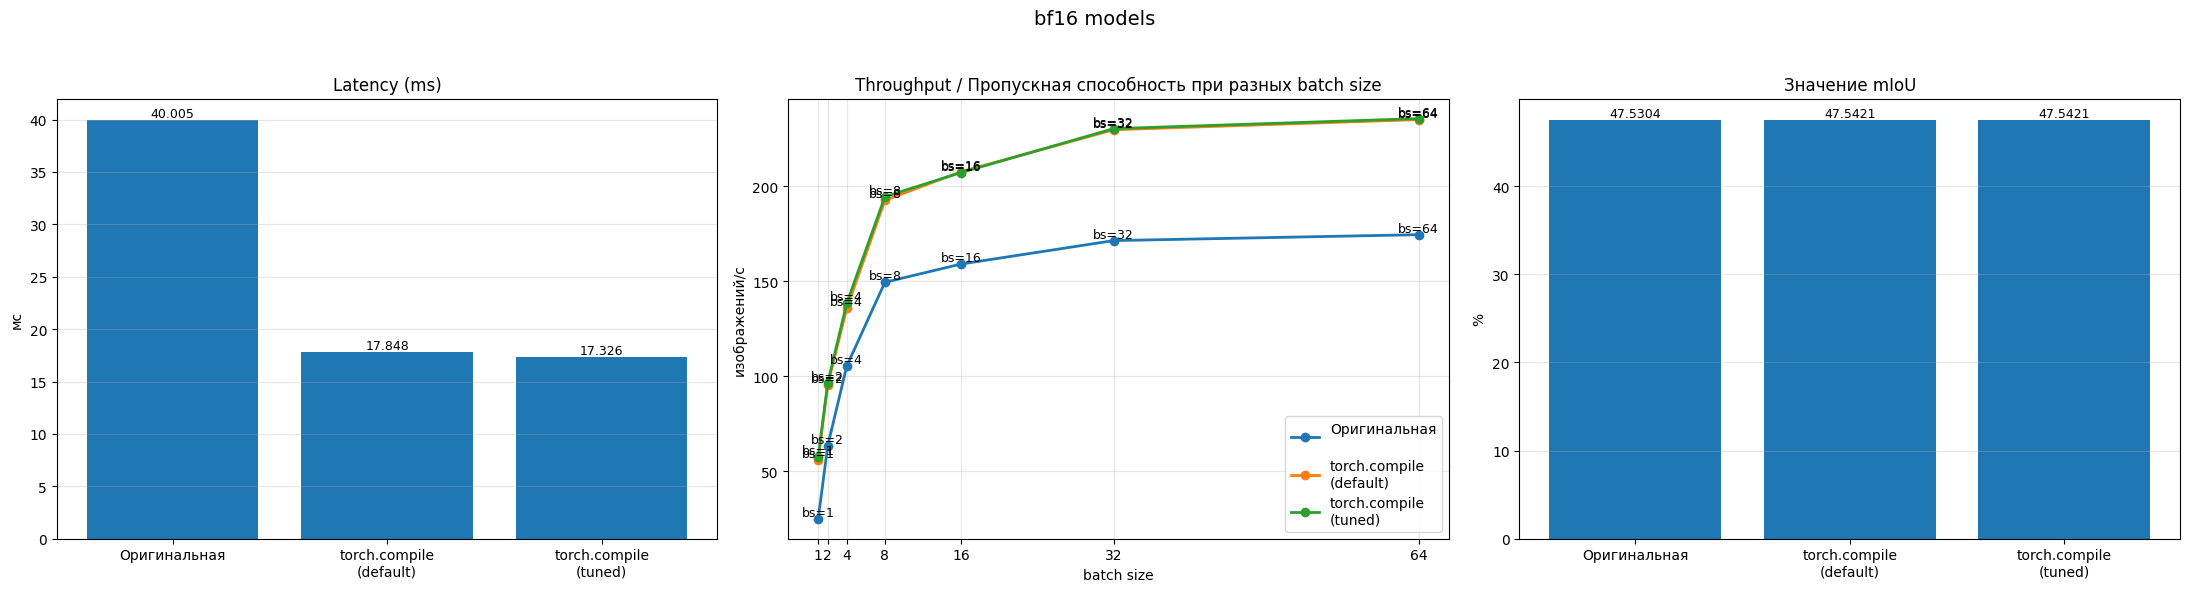

In [34]:
latency_df, throughput_df, metric_df, err_df = show_torch_compile_report(exp_compile)